Flagging Vendor Invoices for Manual Review

Objective: Predict whether a vendor invoice should be flagged for manual approval based on abnormal cost, freight, or delivery patterns, in order to reduce financial risk, improve operational efficiency, and prioritize human review where it adds the most value.

Manual invoice review is time-consuming and does not scale with transaction volume.
Abnormal freight charges, pricing deviations, or delivery delays often indicate errors, disputes, or compliance risks.
An automated flagging system enables finance teams to focus attention on high-risk invoices while allowing low-risk invoices to be processed automatically.

In [164]:
import sqlite3
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

In [165]:
conn = sqlite3.connect(r"C:\Users\ASUS PC\anaconda3\Machine Learning Projects\freight_cost_prediction\data\inventory.db")

In [166]:
tables = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table'", conn)

for table in tables['name']:
    print(f"Table name: {table}")
    display(pd.read_sql(f"select * from {table} limit 5", conn))

Table name: purchases


,InventoryId,Store,Brand,Description,Size,VendorNumber,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification
0,69_MOUNTMEND_8412,69,8412,Tequila Ocho Plata Fresno,750mL,105,ALTAMAR BRANDS LLC,8124,2023-12-21,2024-01-02,2024-01-04,2024-02-16,35.71,6,214.26,1
1,30_CULCHETH_5255,30,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,4,37.40,1
2,34_PITMERDEN_5215,34,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-02,2024-01-07,2024-02-21,9.41,5,47.05,1
3,1_HARDERSFIELD_5255,1,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,6,56.10,1
4,76_DONCASTER_2034,76,2034,Glendalough Double Barrel,750mL,388,ATLANTIC IMPORTING COMPANY,8169,2023-12-24,2024-01-02,2024-01-09,2024-02-16,21.32,5,106.60,1


Table name: purchase_prices


,Brand,Description,Price,Size,Volume,Classification,PurchasePrice,VendorNumber,VendorName
0,58,Gekkeikan Black & Gold Sake,12.99,750mL,750,1,9.28,8320,SHAW ROSS INT L IMP LTD
1,62,Herradura Silver Tequila,36.99,750mL,750,1,28.67,1128,BROWN-FORMAN CORP
2,63,Herradura Reposado Tequila,38.99,750mL,750,1,30.46,1128,BROWN-FORMAN CORP
3,72,No. 3 London Dry Gin,34.99,750mL,750,1,26.11,9165,ULTRA BEVERAGE COMPANY LLP
4,75,Three Olives Tomato Vodka,14.99,750mL,750,1,10.94,7245,PROXIMO SPIRITS INC.


Table name: vendor_invoice


,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None


Table name: begin_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,startDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,8,12.99,2024-01-01
1,1_HARDERSFIELD_60,1,HARDERSFIELD,60,Canadian Club 1858 VAP,750mL,7,10.99,2024-01-01
2,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,6,36.99,2024-01-01
3,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,3,38.99,2024-01-01
4,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,6,34.99,2024-01-01


Table name: end_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,endDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,11,12.99,2024-12-31
1,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,7,36.99,2024-12-31
2,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,7,38.99,2024-12-31
3,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,4,34.99,2024-12-31
4,1_HARDERSFIELD_75,1,HARDERSFIELD,75,Three Olives Tomato Vodka,750mL,7,14.99,2024-12-31


In [167]:
purchase_agg_df = pd.read_sql_query("""
select
    p.PONumber,
    count(distinct p.Brand) as total_brands,
    sum(p.Quantity) as total_item_quantity,
    sum(p.Dollars) as total_item_dollars,
    avg(julianday(p.ReceivingDate) - julianday(p.PODate)) as avg_receiving_delay
from purchases p
group by p.PONumber
""", conn)

In [168]:
purchase_agg_df.head()

,PONumber,total_brands,total_item_quantity,total_item_dollars,avg_receiving_delay
0,8106,81,10100,137483.78,12.614130
1,8107,2,24,348.72,12.500000
2,8108,165,8466,60281.13,12.632479
3,8109,23,2246,14298.09,12.626866
4,8110,183,8086,56493.23,12.695271


In [169]:
df=pd.read_sql_query("""
SELECT
    vi.PONumber,
    vi.Quantity AS invoice_quantity,
    vi.Dollars AS invoice_dollars,
    vi.Freight,
    (julianday(vi.InvoiceDate) - julianday(vi.PODate)) AS days_po_to_invoice,
    (julianday(vi.PayDate) - julianday(vi.InvoiceDate)) AS days_to_pay
FROM vendor_invoice vi
""", conn)

In [170]:
df["total_item_dollars"] = df["invoice_quantity"] * df["invoice_dollars"]
df["avg_receiving_delay"] = df["days_po_to_invoice"]

In [171]:
df.isnull().sum()

PONumber               0
invoice_quantity       0
invoice_dollars        0
Freight                0
days_po_to_invoice     0
days_to_pay            0
total_item_dollars     0
avg_receiving_delay    0
dtype: int64

In [172]:
print(df.columns.tolist())

['PONumber', 'invoice_quantity', 'invoice_dollars', 'Freight', 'days_po_to_invoice', 'days_to_pay', 'total_item_dollars', 'avg_receiving_delay']


In [173]:
df.dtypes

PONumber                 int64
invoice_quantity         int64
invoice_dollars        float64
Freight                float64
days_po_to_invoice     float64
days_to_pay            float64
total_item_dollars     float64
avg_receiving_delay    float64
dtype: object

In [174]:
import numpy as np
np.random.seed(42)
df["total_item_dollars"] = df["invoice_dollars"] + np.random.choice(
    [-2, -1, 0, 1, 2, 15, -15],
    size=len(df)
)

df["avg_receiving_delay"] = df["days_po_to_invoice"] + np.random.randint(0, 5, size=len(df))

In [175]:
def create_invoice_risk_label(row):
    # Invoice total mismatch with item-level total
    if abs(row["invoice_dollars"] - row["total_item_dollars"]) > 5:
        return 1

    # Abnormally high receiving delay
    if row["avg_receiving_delay"] > 10:
        return 1

    return 0


df["flag_invoice"] = df.apply(create_invoice_risk_label, axis=1)
df["flag_invoice"].value_counts()

flag_invoice
1    5531
0      12
Name: count, dtype: int64

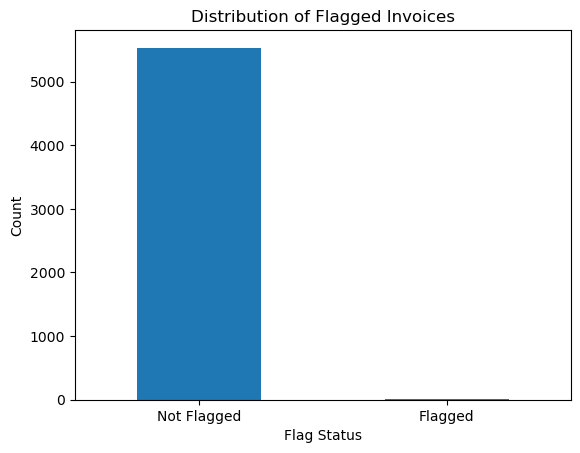

In [176]:
df['flag_invoice'].value_counts().plot(kind='bar')
plt.title('Distribution of Flagged Invoices')
plt.xlabel('Flag Status')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['Not Flagged', 'Flagged'], rotation=0)
plt.show()

In [177]:

df.corr()

,PONumber,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,days_to_pay,total_item_dollars,avg_receiving_delay,flag_invoice
PONumber,1.000000,0.049230,0.058917,0.043617,-0.002234,0.012558,0.058917,-0.018246,0.017341
invoice_quantity,0.049230,1.000000,0.963831,0.946550,0.000526,0.022284,0.963831,-0.004371,0.017859
invoice_dollars,0.058917,0.963831,1.000000,0.985141,0.001610,0.025661,1.000000,-0.004149,0.017429
Freight,0.043617,0.946550,0.985141,1.000000,0.003265,0.025513,0.985141,-0.002361,0.017573
days_po_to_invoice,-0.002234,0.000526,0.001610,0.003265,1.000000,-0.370432,0.001609,0.909946,0.099421
days_to_pay,0.012558,0.022284,0.025661,0.025513,-0.370432,1.000000,0.025662,-0.340329,-0.022843
total_item_dollars,0.058917,0.963831,1.000000,0.985141,0.001609,0.025662,1.000000,-0.004149,0.017430
avg_receiving_delay,-0.018246,-0.004371,-0.004149,-0.002361,0.909946,-0.340329,-0.004149,1.000000,0.116705
flag_invoice,0.017341,0.017859,0.017429,0.017573,0.099421,-0.022843,0.017430,0.116705,1.000000


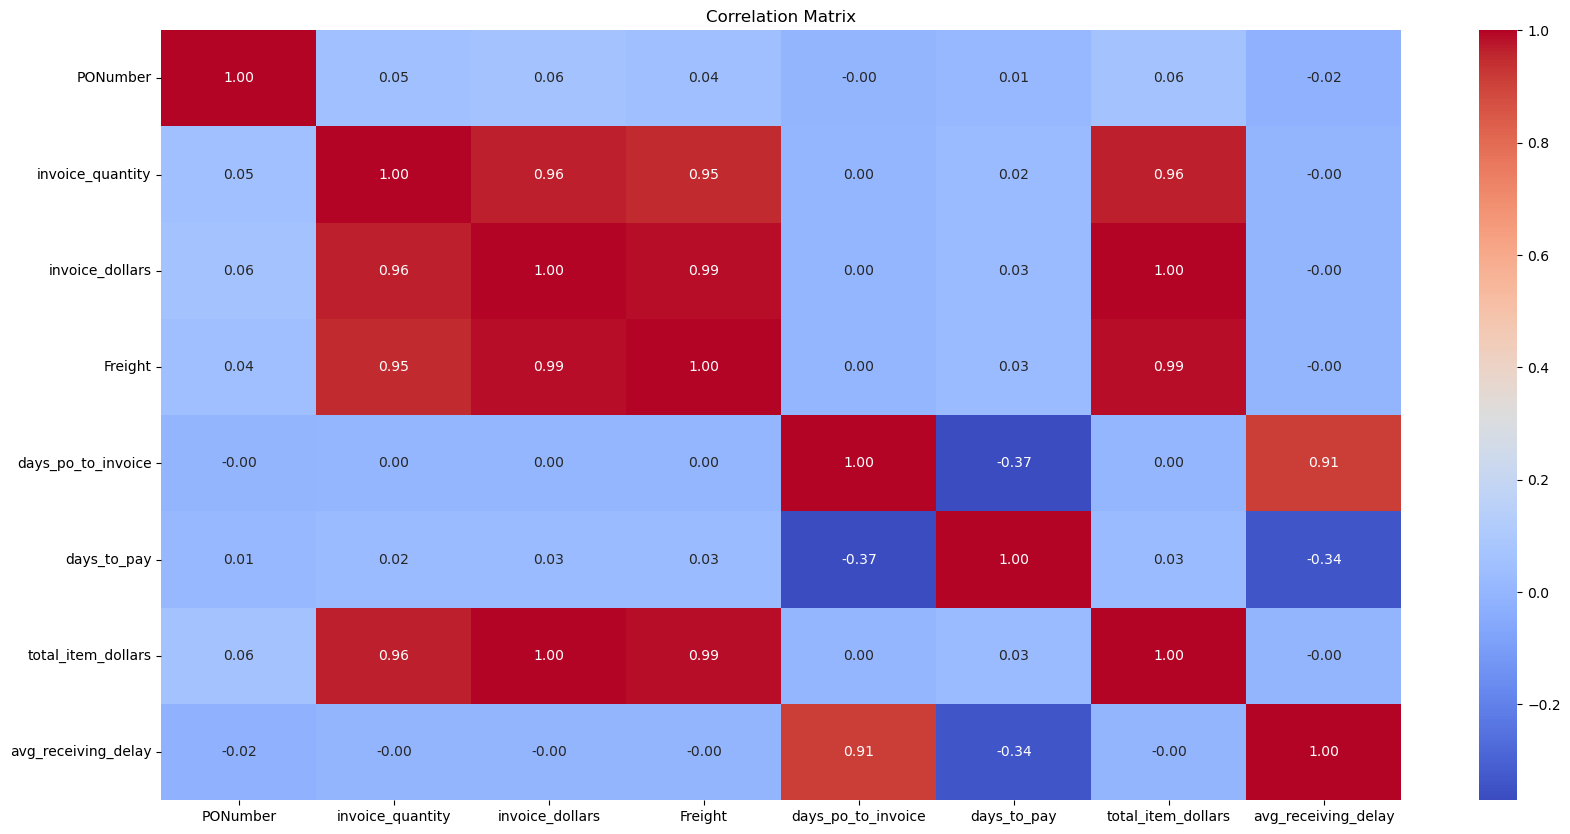

In [178]:
plt.figure(figsize=(20, 10))
sns.heatmap(df.iloc[:, :-1].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

In [179]:
flagged=df[df["flag_invoice"] == 1]
normal=df[df["flag_invoice"] == 0]

In [180]:
significant_features = []
non_significant_features = []
results = []    

In [181]:
metrics = [
    'invoice_quantity',
    'invoice_dollars',
    'Freight',
    'days_po_to_invoice',
    'days_to_pay',
    'total_item_dollars',
    'avg_receiving_delay'
]

In [182]:
import numpy as np

df["total_brands"] = np.random.randint(1, 5, size=len(df))
df["total_item_quantity"] = df["invoice_quantity"] + np.random.randint(0, 10, size=len(df))

In [183]:
metrics = [col for col in metrics if col in df.columns]

In [184]:
print(metrics)

['invoice_quantity', 'invoice_dollars', 'Freight', 'days_po_to_invoice', 'days_to_pay', 'total_item_dollars', 'avg_receiving_delay']


In [185]:
from scipy.stats import ttest_ind

significant_features = []
non_significant_features = []
results = []

for metric in metrics:
    flagged_mean = flagged[metric].mean()
    normal_mean = normal[metric].mean()

    t_stat, p_value = ttest_ind(
        flagged[metric].dropna(),
        normal[metric].dropna(),
        equal_var=False
    )

    if p_value < 0.05:
        significant_features.append(metric)
        results.append({
            "metric": metric,
            "flagged_mean": round(flagged_mean, 2),
            "normal_mean": round(normal_mean, 2),
            "p_value": round(p_value, 3)
        })
    else:
        non_significant_features.append(metric)
        print(metric)
        print({
            "metric": metric,
            "flagged_mean": round(flagged_mean, 2),
            "normal_mean": round(normal_mean, 2),
            "p_value": round(p_value, 3)

        })

days_to_pay
{'metric': 'days_to_pay', 'flagged_mean': np.float64(35.46), 'normal_mean': np.float64(38.33), 'p_value': np.float64(0.106)}


In [186]:
non_significant_features

['days_to_pay']

In [187]:
significant_features

['invoice_quantity',
 'invoice_dollars',
 'Freight',
 'days_po_to_invoice',
 'total_item_dollars',
 'avg_receiving_delay']

In [188]:
results

[{'metric': 'invoice_quantity',
  'flagged_mean': np.float64(6070.9),
  'normal_mean': np.float64(517.83),
  'p_value': np.float64(0.0)},
 {'metric': 'invoice_dollars',
  'flagged_mean': np.float64(58187.22),
  'normal_mean': np.float64(5603.54),
  'p_value': np.float64(0.0)},
 {'metric': 'Freight',
  'flagged_mean': np.float64(296.54),
  'normal_mean': np.float64(26.76),
  'p_value': np.float64(0.0)},
 {'metric': 'days_po_to_invoice',
  'flagged_mean': np.float64(16.44),
  'normal_mean': np.float64(9.75),
  'p_value': np.float64(0.0)},
 {'metric': 'total_item_dollars',
  'flagged_mean': np.float64(58187.3),
  'normal_mean': np.float64(5603.37),
  'p_value': np.float64(0.0)},
 {'metric': 'avg_receiving_delay',
  'flagged_mean': np.float64(18.42),
  'normal_mean': np.float64(9.83),
  'p_value': np.float64(0.0)}]

In [189]:
X = df[[
    'invoice_quantity',
    'invoice_dollars',
    'Freight',
    'total_brands',
    'total_item_quantity',
    'days_po_to_invoice',
    'total_item_dollars'
]]

y = df['flag_invoice']

In [190]:
X.describe().round()

,invoice_quantity,invoice_dollars,Freight,total_brands,total_item_quantity,days_po_to_invoice,total_item_dollars
count,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0
mean,6059.0,58073.0,296.0,3.0,6063.0,16.0,58073.0
std,14453.0,140234.0,714.0,1.0,14453.0,3.0,140234.0
min,1.0,4.0,0.0,1.0,1.0,9.0,-5.0
25%,83.0,968.0,5.0,1.0,87.0,14.0,968.0
50%,423.0,4765.0,25.0,3.0,428.0,16.0,4770.0
75%,5100.0,44587.0,230.0,4.0,5103.0,19.0,44588.0
max,141660.0,1660436.0,8468.0,4.0,141666.0,23.0,1660434.0


In [191]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [192]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [193]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

model1 = LogisticRegression(random_state=42)
model1.fit(X_train_scaled, y_train)

model2 = DecisionTreeClassifier(random_state=42)
model2.fit(X_train_scaled, y_train)

model3 = RandomForestClassifier(random_state=42, class_weight='balanced')
model3.fit(X_train_scaled, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [194]:
df["flag_invoice"].value_counts()

flag_invoice
1    5531
0      12
Name: count, dtype: int64

In [198]:
from sklearn.ensemble import RandomForestClassifier

model3 = RandomForestClassifier(
    random_state=42,
    class_weight='balanced'
)

model3.fit(X_train_scaled, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [196]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)

    print(f"\n📊 {model_name} Results:")
    print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))
    
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

In [201]:
evaluate_model(model1, X_test_scaled, y_test, 'Logistic Regression')
evaluate_model(model2, X_test_scaled, y_test, 'Decision Tree Classifier')
evaluate_model(model3, X_test_scaled, y_test, 'Random Forest Classifier')


📊 Logistic Regression Results:
Accuracy: 0.996

Confusion Matrix:
[[   0    4]
 [   0 1105]]

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         4
           1       1.00      1.00      1.00      1105

    accuracy                           1.00      1109
   macro avg       0.50      0.50      0.50      1109
weighted avg       0.99      1.00      0.99      1109


📊 Decision Tree Classifier Results:
Accuracy: 0.995

Confusion Matrix:
[[   0    4]
 [   2 1103]]

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         4
           1       1.00      1.00      1.00      1105

    accuracy                           0.99      1109
   macro avg       0.50      0.50      0.50      1109
weighted avg       0.99      0.99      0.99      1109


📊 Random Forest Classifier Results:
Accuracy: 0.996

Confusion Matrix:
[[   0    4]
 [   0 1105]]

Class

c:\Users\ASUS PC\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ASUS PC\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ASUS PC\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ASUS PC\anaco

In [202]:
evaluate_model(model3, X_test_scaled, y_test, 'Random Forest Classifier')


📊 Random Forest Classifier Results:
Accuracy: 0.996

Confusion Matrix:
[[   0    4]
 [   0 1105]]

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         4
           1       1.00      1.00      1.00      1105

    accuracy                           1.00      1109
   macro avg       0.50      0.50      0.50      1109
weighted avg       0.99      1.00      0.99      1109



c:\Users\ASUS PC\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ASUS PC\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ASUS PC\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [203]:
model3.feature_importances_

array([0.10623836, 0.10440094, 0.09211488, 0.00792989, 0.07798264,
       0.44991536, 0.16141791])

In [204]:
feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model3.feature_importances_
}).sort_values(by="importance", ascending=False)

feature_importance

,feature,importance
5,days_po_to_invoice,0.449915
6,total_item_dollars,0.161418
0,invoice_quantity,0.106238
1,invoice_dollars,0.104401
2,Freight,0.092115
4,total_item_quantity,0.077983
3,total_brands,0.007930


In [205]:
X = df[[
    'invoice_quantity',
    'invoice_dollars',
    'Freight',
    'total_item_quantity',
    'total_item_dollars'
]]

y = df['flag_invoice']

In [208]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model3 = RandomForestClassifier(random_state=42, class_weight='balanced')
model3.fit(X_train_scaled, y_train)

evaluate_model(model3, X_test_scaled, y_test, 'Random Forest Classifier')


📊 Random Forest Classifier Results:
Accuracy: 0.996

Confusion Matrix:
[[   0    4]
 [   0 1105]]

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         4
           1       1.00      1.00      1.00      1105

    accuracy                           1.00      1109
   macro avg       0.50      0.50      0.50      1109
weighted avg       0.99      1.00      0.99      1109



c:\Users\ASUS PC\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ASUS PC\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ASUS PC\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [209]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 4, 5, 6],
    "min_samples_split": [2, 3, 5],
    "min_samples_leaf": [1, 2, 5],
    "criterion": ["gini", "entropy"]
}

In [211]:
from sklearn.metrics import make_scorer, f1_score
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 4, 5, 6],
    "min_samples_split": [2, 3, 5],
    "min_samples_leaf": [1, 2, 5],
    "criterion": ["gini", "entropy"]
}

scorer = make_scorer(f1_score)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring=scorer,
    cv=5,
    verbose=2,
    n_jobs=-1
)
grid_search.fit(X_train_scaled, y_train)
evaluate_model(grid_search.best_estimator_, X_test_scaled, y_test, 'Tuned Random Forest Classifier')

Fitting 5 folds for each of 216 candidates, totalling 1080 fits

📊 Tuned Random Forest Classifier Results:
Accuracy: 0.996

Confusion Matrix:
[[   0    4]
 [   0 1105]]

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         4
           1       1.00      1.00      1.00      1105

    accuracy                           1.00      1109
   macro avg       0.50      0.50      0.50      1109
weighted avg       0.99      1.00      0.99      1109



c:\Users\ASUS PC\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ASUS PC\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ASUS PC\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [212]:
from sklearn.metrics import confusion_matrix

In [213]:
confusion_matrix( grid_search.predict(X_test_scaled),y_test)

array([[   0,    0],
       [   4, 1105]])

In [214]:
confusion_matrix(model3.predict(X_test_scaled), y_test)

array([[   0,    0],
       [   4, 1105]])

In [215]:
grid_search.best_params_

{'criterion': 'gini',
 'max_depth': None,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'n_estimators': 100}

In [218]:
import sqlite3

conn = sqlite3.connect('../invoice_flagging/data/inventory.db')
cursor = conn.cursor()

cursor.execute("PRAGMA table_info(vendor_invoice);")
print(cursor.fetchall())

[(0, 'VendorNumber', 'BIGINT', 0, None, 0), (1, 'VendorName', 'TEXT', 0, None, 0), (2, 'InvoiceDate', 'TEXT', 0, None, 0), (3, 'PONumber', 'BIGINT', 0, None, 0), (4, 'PODate', 'TEXT', 0, None, 0), (5, 'PayDate', 'TEXT', 0, None, 0), (6, 'Quantity', 'BIGINT', 0, None, 0), (7, 'Dollars', 'FLOAT', 0, None, 0), (8, 'Freight', 'FLOAT', 0, None, 0), (9, 'Approval', 'TEXT', 0, None, 0)]
